# L02 — Definitions, Three Principles (precise), and Dynamics in B₀

**Companion notebook to `L02_summary.md`.**

This notebook turns the lecture's core ideas into runnable code:

1. The scanner coordinate system and longitudinal/transversal decomposition
2. Complex-plane notation for transversal vectors
3. Computing the equilibrium magnetization M₀ (full quantum formula and high-T approximation)
4. The cross product and a sanity check of its properties
5. Solving the Bloch equation in a static B₀ numerically and comparing to the analytic Larmor solution
6. An animation of M precessing

By the end you'll have a tiny Bloch simulator that you can extend in upcoming lectures (RF pulses, gradients, relaxation).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from scipy.integrate import solve_ivp

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 100

## 1. The scanner coordinate system

We define the standard right-handed (x, y, z) basis with **B₀** along +z. We then verify right-handedness via the cross product: $\mathbf{e}_x \times \mathbf{e}_y = \mathbf{e}_z$.

In [2]:
ex = np.array([1.0, 0.0, 0.0])
ey = np.array([0.0, 1.0, 0.0])
ez = np.array([0.0, 0.0, 1.0])

print('e_x × e_y =', np.cross(ex, ey), '   (should be e_z)')
print('e_y × e_z =', np.cross(ey, ez), '   (should be e_x)')
print('e_z × e_x =', np.cross(ez, ex), '   (should be e_y)')
print('e_x × e_x =', np.cross(ex, ex), '   (should be 0 — parallel)')

B0_strength = 3.0  # Tesla
B0 = B0_strength * ez
print('\nB_0 vector at 3 T:', B0, 'T')

e_x × e_y = [0. 0. 1.]    (should be e_z)
e_y × e_z = [1. 0. 0.]    (should be e_x)
e_z × e_x = [0. 1. 0.]    (should be e_y)
e_x × e_x = [0. 0. 0.]    (should be 0 — parallel)

B_0 vector at 3 T: [0. 0. 3.] T


### 1.1 Longitudinal/transversal decomposition

Any vector $\mathbf{v}$ splits as $\mathbf{v} = \mathbf{v}_\parallel + \mathbf{v}_\perp$ where $\mathbf{v}_\parallel = (0, 0, v_z)^T$ and $\mathbf{v}_\perp = (v_x, v_y, 0)^T$.

In [3]:
def decompose(v):
    """Split v into its longitudinal (along z) and transversal (in xy) parts."""
    v = np.asarray(v, dtype=float)
    v_par = np.array([0.0, 0.0, v[2]])
    v_perp = np.array([v[0], v[1], 0.0])
    return v_par, v_perp

v = np.array([3.0, 4.0, 5.0])
v_par, v_perp = decompose(v)

print(f'v        = {v}')
print(f'v_∥      = {v_par}     (longitudinal, along B_0)')
print(f'v_⊥      = {v_perp}     (transversal, in xy-plane)')
print(f'sum      = {v_par + v_perp}     (should equal v)')
print(f'|v_⊥|    = {np.linalg.norm(v_perp):.4f}     (should be 5 = sqrt(3²+4²))')

v        = [3. 4. 5.]
v_∥      = [0. 0. 5.]     (longitudinal, along B_0)
v_⊥      = [3. 4. 0.]     (transversal, in xy-plane)
sum      = [3. 4. 5.]     (should equal v)
|v_⊥|    = 5.0000     (should be 5 = sqrt(3²+4²))


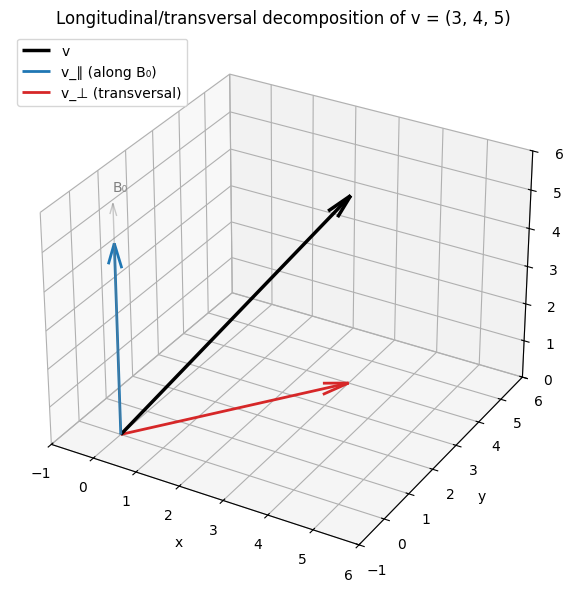

In [4]:
# Visualize the decomposition
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

origin = np.zeros(3)
ax.quiver(*origin, *v, color='black', arrow_length_ratio=0.08, lw=2.5, label='v')
ax.quiver(*origin, *v_par, color='tab:blue', arrow_length_ratio=0.12, lw=2, label='v_∥ (along B₀)')
ax.quiver(*origin, *v_perp, color='tab:red', arrow_length_ratio=0.12, lw=2, label='v_⊥ (transversal)')

# Draw a faint B_0 indicator
ax.quiver(*origin, 0, 0, 6, color='gray', alpha=0.4, arrow_length_ratio=0.05, lw=1)
ax.text(0, 0, 6.3, 'B₀', color='gray')

ax.set_xlim([-1, 6]); ax.set_ylim([-1, 6]); ax.set_zlim([0, 6])
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Longitudinal/transversal decomposition of v = (3, 4, 5)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

## 2. Complex-plane notation

Transversal vectors $(v_x, v_y)$ pack neatly into a complex number:
$$v_+ = v_x + i\,v_y = |v_+|\,e^{i\theta_v}$$

Why this is so useful: rotations of the transversal plane are just multiplication by $e^{i\phi}$. We'll use this constantly when we get to RF pulses and signal demodulation.

In [5]:
def to_complex(v_perp):
    """Convert a transversal vector (vx, vy, 0) to its complex-plane form v+ = vx + i*vy."""
    return complex(v_perp[0], v_perp[1])

def from_complex(v_plus):
    """Convert v+ back to a 3-vector (vx, vy, 0)."""
    return np.array([v_plus.real, v_plus.imag, 0.0])

v_perp = np.array([3.0, 4.0, 0.0])
v_plus = to_complex(v_perp)
print(f'v_⊥ = {v_perp}')
print(f'v_+ = {v_plus}')
print(f'|v_+| = {abs(v_plus):.4f}     (should equal |v_⊥| = 5)')
print(f'θ_v   = {np.degrees(np.angle(v_plus)):.2f}°   (arctan2(4, 3) ≈ 53.13°)')

# Round-trip check
print(f'\nRound-trip: {from_complex(v_plus)}     (should match v_⊥)')

# Demonstrate the conjugate v_- = v_+*
v_minus = v_plus.conjugate()
print(f'\nv_- = v_x - i*v_y = {v_minus}')
print(f'v_+ * v_- = {v_plus * v_minus}     (real, equals |v_+|² = 25)')

v_⊥ = [3. 4. 0.]
v_+ = (3+4j)
|v_+| = 5.0000     (should equal |v_⊥| = 5)
θ_v   = 53.13°   (arctan2(4, 3) ≈ 53.13°)

Round-trip: [3. 4. 0.]     (should match v_⊥)

v_- = v_x - i*v_y = (3-4j)
v_+ * v_- = (25+0j)     (real, equals |v_+|² = 25)


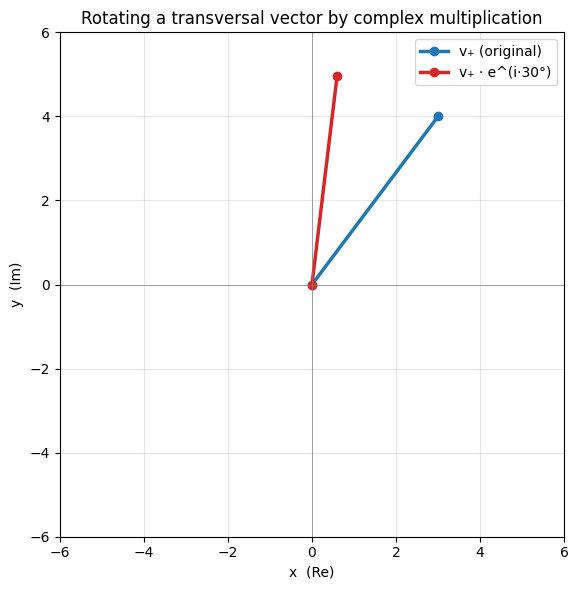

In [6]:
# Rotate a transversal vector by 30° using complex multiplication
phi = np.radians(30)
v_rotated = v_plus * np.exp(1j * phi)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, v_plus.real], [0, v_plus.imag], 'o-', color='tab:blue', lw=2.5, label='v₊ (original)')
ax.plot([0, v_rotated.real], [0, v_rotated.imag], 'o-', color='tab:red', lw=2.5,
        label=f'v₊ · e^(i·30°)')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlim(-6, 6); ax.set_ylim(-6, 6); ax.set_aspect('equal')
ax.set_xlabel('x  (Re)'); ax.set_ylabel('y  (Im)')
ax.set_title('Rotating a transversal vector by complex multiplication')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. The equilibrium magnetization M₀

From the lecture's bonus derivation:

$$M_0 = \frac{\rho \gamma \hbar}{2}\tanh\!\left(\frac{\gamma\hbar B_0}{2 k_B T_K}\right) \approx \frac{\rho}{4}\cdot\frac{\gamma^2 \hbar^2}{k_B T_K}\,B_0$$

The right-hand approximation is the high-temperature limit (excellent at body temperature).

In [7]:
# Physical constants (SI)
GAMMA_PROTON = 2.675e8   # rad/s/T  — proton gyromagnetic ratio
HBAR         = 1.0546e-34  # J·s
K_B          = 1.3806e-23  # J/K
T_BODY       = 310.0       # K (≈ 37 °C)
RHO_WATER    = 6.7e28      # protons/m³ (rough estimate for water)

def M0_exact(B0, rho=RHO_WATER, T=T_BODY):
    """Equilibrium magnetization, full quantum-mechanical formula."""
    x = GAMMA_PROTON * HBAR * B0 / (2 * K_B * T)
    return rho * GAMMA_PROTON * HBAR / 2 * np.tanh(x)

def M0_high_T(B0, rho=RHO_WATER, T=T_BODY):
    """Equilibrium magnetization in the high-temperature limit (tanh x ≈ x)."""
    return rho / 4 * (GAMMA_PROTON**2 * HBAR**2) / (K_B * T) * B0

for B in [0.5, 1.5, 3.0, 7.0]:
    x = GAMMA_PROTON * HBAR * B / (2 * K_B * T_BODY)
    print(f'B₀ = {B:>4.1f} T   '
          f'γħB₀/(2kT) = {x:.3e}   '
          f'M₀(exact)  = {M0_exact(B):.4e} A/m   '
          f'M₀(high-T) = {M0_high_T(B):.4e} A/m')

B₀ =  0.5 T   γħB₀/(2kT) = 1.648e-06   M₀(exact)  = 1.5573e-03 A/m   M₀(high-T) = 1.5573e-03 A/m
B₀ =  1.5 T   γħB₀/(2kT) = 4.944e-06   M₀(exact)  = 4.6720e-03 A/m   M₀(high-T) = 4.6720e-03 A/m
B₀ =  3.0 T   γħB₀/(2kT) = 9.887e-06   M₀(exact)  = 9.3439e-03 A/m   M₀(high-T) = 9.3439e-03 A/m
B₀ =  7.0 T   γħB₀/(2kT) = 2.307e-05   M₀(exact)  = 2.1803e-02 A/m   M₀(high-T) = 2.1803e-02 A/m


Notice the high-T approximation is essentially perfect at every clinical field strength.

**Now let's verify the punchline of the lecture: $M_0 \propto B_0/T_K$.**

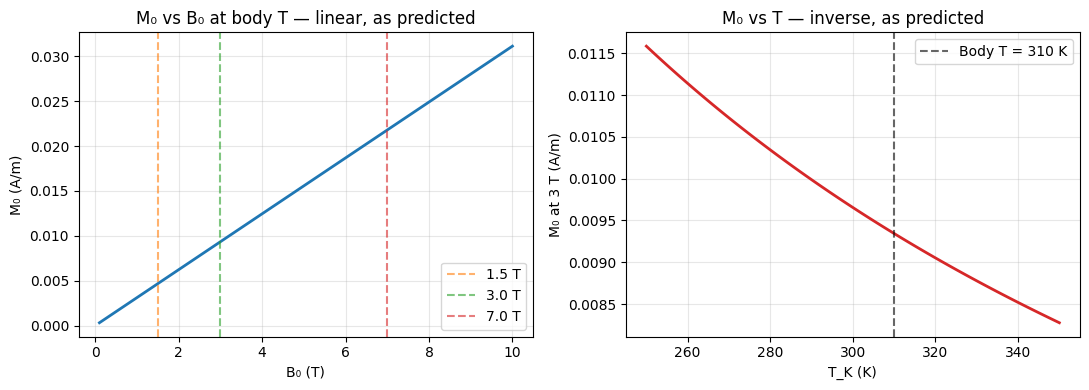

In [8]:
B_range = np.linspace(0.1, 10, 100)
T_range = np.linspace(250, 350, 100)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].plot(B_range, [M0_exact(B) for B in B_range], lw=2)
for clinical_B, color in zip([1.5, 3.0, 7.0], ['C1', 'C2', 'C3']):
    axs[0].axvline(clinical_B, color=color, ls='--', alpha=0.6, label=f'{clinical_B} T')
axs[0].set_xlabel('B₀ (T)'); axs[0].set_ylabel('M₀ (A/m)')
axs[0].set_title('M₀ vs B₀ at body T — linear, as predicted')
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(T_range, [M0_exact(3.0, T=T) for T in T_range], lw=2, color='C3')
axs[1].axvline(T_BODY, color='k', ls='--', alpha=0.6, label='Body T = 310 K')
axs[1].set_xlabel('T_K (K)'); axs[1].set_ylabel('M₀ at 3 T (A/m)')
axs[1].set_title('M₀ vs T — inverse, as predicted')
axs[1].legend(); axs[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 4. The cross product — a quick sanity check

Verify the four properties from the summary numerically.

In [9]:
rng = np.random.default_rng(42)
a = rng.standard_normal(3)
b = rng.standard_normal(3)
d = rng.standard_normal(3)

# 1. Parallel vectors → zero
print('a × a =', np.cross(a, a), '       (parallel → 0)')

# 2. Perpendicular vectors → |a||b|
u = np.array([1.0, 0.0, 0.0])
v = np.array([0.0, 1.0, 0.0])
print(f'|u×v| for u⊥v of unit length: {np.linalg.norm(np.cross(u, v)):.4f}    (should be 1)')

# 3. Anti-commutative
print('a × b + b × a =', np.cross(a, b) + np.cross(b, a), '   (should be 0)')

# 4. Linear in first argument
lhs = np.cross(a + d, b)
rhs = np.cross(a, b) + np.cross(d, b)
print(f'\n(a+d)×b - (a×b + d×b) = {lhs - rhs}   (should be 0)')

# 5. |a×b| = |a||b|sinθ
cos_theta = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
sin_theta = np.sqrt(1 - cos_theta**2)
print(f'\n|a×b|         = {np.linalg.norm(np.cross(a, b)):.4f}')
print(f'|a||b|sinθ    = {np.linalg.norm(a) * np.linalg.norm(b) * sin_theta:.4f}')

a × a = [0. 0. 0.]        (parallel → 0)
|u×v| for u⊥v of unit length: 1.0000    (should be 1)
a × b + b × a = [0. 0. 0.]    (should be 0)

(a+d)×b - (a×b + d×b) = [ 0.  0. -0.]   (should be 0)

|a×b|         = 3.0506
|a||b|sinθ    = 3.0506


## 5. The Bloch equation in B₀ (no relaxation)

$$\dot{\mathbf{M}}(t) = \gamma \mathbf{B}_0 \times \mathbf{M}(t)$$

We solve this numerically with `scipy.solve_ivp` and compare to the analytic Larmor solution.

**Initial condition:** assume an RF pulse has already tipped magnetization fully into the transversal plane: $\mathbf{M}(0) = (M_0, 0, 0)^T$. (We'll learn how to actually create such an initial state in the next lecture on excitation.)

Larmor frequency (visualization γ): ω₀ = 6283.19 rad/s   (ν₀ = 1000.0 Hz)
Period: T = 1.000 ms


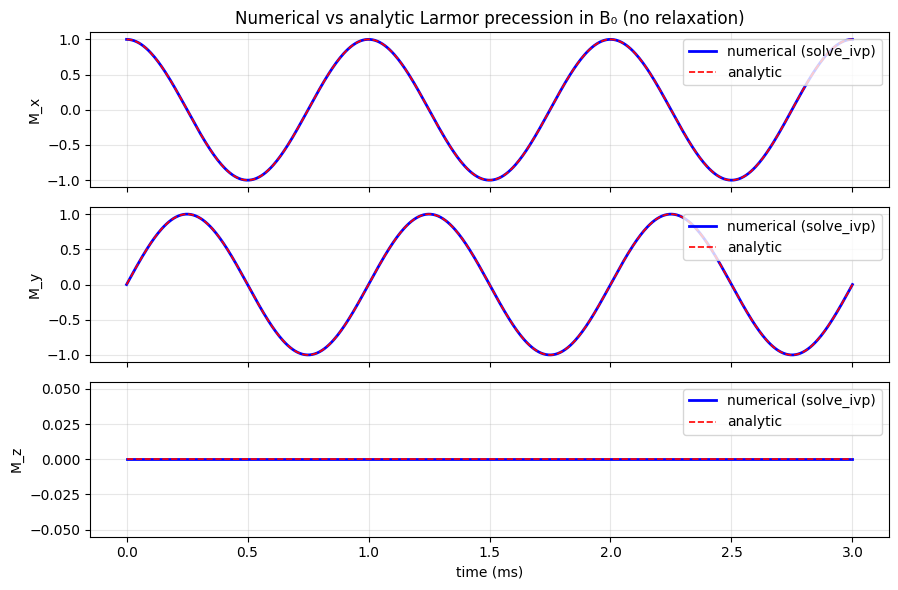


|M| min = 1.000000,  max = 1.000000   (should stay at 1.0)
M_z range: [0.00e+00, 0.00e+00]   (should stay at 0)


In [10]:
def bloch_no_relax(t, M, B, gamma=GAMMA_PROTON):
    """
    Right-hand side of the Bloch equation without relaxation.
    
    Ṁ = γ B × M
    """
    return gamma * np.cross(B, M)

# Use a SLOWED-DOWN gyromagnetic ratio for visualization purposes only.
# At real γ and 3 T, M precesses at ~128 MHz — we'd need femtosecond steps to see it.
# We pick a small γ' so 1 full period takes 1 ms in our plots. The physics is identical.
GAMMA_VIS = 2 * np.pi * 1000 / B0_strength   # so that ω₀ = 2π·1000 rad/s → period = 1 ms

M0_val = 1.0   # normalized magnitude
M_init = np.array([M0_val, 0.0, 0.0])    # tipped into +x
B = np.array([0.0, 0.0, B0_strength])

t_span = (0, 0.003)   # 3 ms
t_eval = np.linspace(*t_span, 600)

sol = solve_ivp(
    fun=lambda t, M: bloch_no_relax(t, M, B, gamma=GAMMA_VIS),
    t_span=t_span, y0=M_init, t_eval=t_eval,
    rtol=1e-9, atol=1e-12,
)

# Analytic solution
omega0 = GAMMA_VIS * B0_strength
Mx_an = M0_val * np.cos(omega0 * t_eval)
My_an = M0_val * np.sin(omega0 * t_eval)
Mz_an = np.zeros_like(t_eval)

print(f'Larmor frequency (visualization γ): ω₀ = {omega0:.2f} rad/s   (ν₀ = {omega0/(2*np.pi):.1f} Hz)')
print(f'Period: T = {2*np.pi/omega0*1e3:.3f} ms')

fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
labels = ['M_x', 'M_y', 'M_z']
analytic = [Mx_an, My_an, Mz_an]
for i, (lbl, an) in enumerate(zip(labels, analytic)):
    axs[i].plot(t_eval * 1e3, sol.y[i], 'b-', lw=2, label='numerical (solve_ivp)')
    axs[i].plot(t_eval * 1e3, an, 'r--', lw=1.2, label='analytic')
    axs[i].set_ylabel(lbl); axs[i].grid(alpha=0.3); axs[i].legend(loc='upper right')
axs[-1].set_xlabel('time (ms)')
axs[0].set_title('Numerical vs analytic Larmor precession in B₀ (no relaxation)')
plt.tight_layout(); plt.show()

# Check magnitude conservation
M_mag = np.linalg.norm(sol.y, axis=0)
print(f'\n|M| min = {M_mag.min():.6f},  max = {M_mag.max():.6f}   (should stay at 1.0)')
print(f'M_z range: [{sol.y[2].min():.2e}, {sol.y[2].max():.2e}]   (should stay at 0)')

Numerics and analytic match to machine precision — the Bloch equation in a static field really does give pure circular precession.

Note also that $M_z$ stays at zero (longitudinal conservation) and $|\mathbf{M}|$ stays at 1 (the static field can rotate **M** but cannot stretch it).

### 5.1 What if we start with a longitudinal component too?

Set $\mathbf{M}(0) = (\sin\alpha, 0, \cos\alpha)^T$ — magnetization tipped by flip angle $\alpha$. The transversal part precesses, the longitudinal part is unchanged.

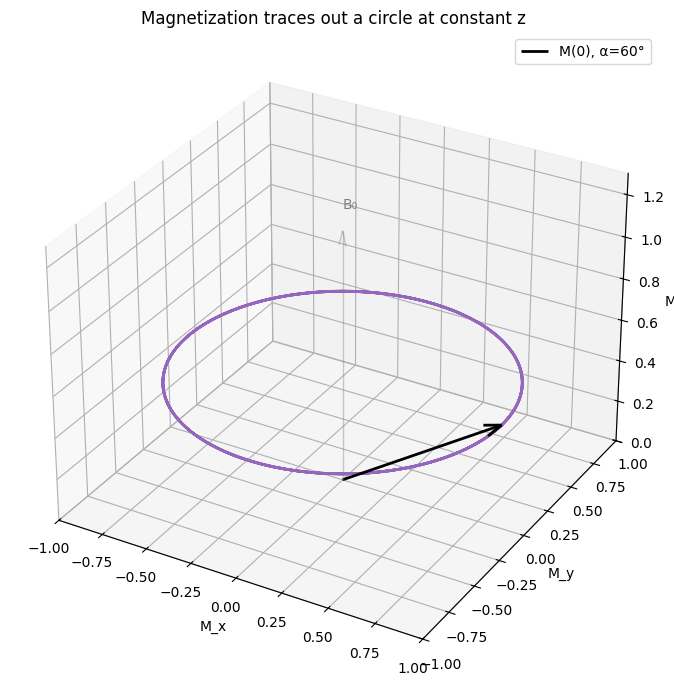

M_z over the trajectory:  min=0.5000, max=0.5000
cos(α) = 0.5000     → M_z is conserved at this value, as predicted.


In [11]:
alpha = np.radians(60)
M_init = np.array([np.sin(alpha), 0.0, np.cos(alpha)])

sol = solve_ivp(
    fun=lambda t, M: bloch_no_relax(t, M, B, gamma=GAMMA_VIS),
    t_span=t_span, y0=M_init, t_eval=t_eval,
    rtol=1e-9, atol=1e-12,
)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=2, color='tab:purple')
ax.quiver(0, 0, 0, *M_init, color='black', lw=2, arrow_length_ratio=0.1, label=f'M(0), α={np.degrees(alpha):.0f}°')
ax.quiver(0, 0, 0, 0, 0, 1.2, color='gray', alpha=0.4, lw=1, arrow_length_ratio=0.06)
ax.text(0, 0, 1.3, 'B₀', color='gray')

ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(0, 1.3)
ax.set_xlabel('M_x'); ax.set_ylabel('M_y'); ax.set_zlabel('M_z')
ax.set_title('Magnetization traces out a circle at constant z')
ax.legend()
plt.tight_layout(); plt.show()

print(f'M_z over the trajectory:  min={sol.y[2].min():.4f}, max={sol.y[2].max():.4f}')
print(f'cos(α) = {np.cos(alpha):.4f}     → M_z is conserved at this value, as predicted.')

## 6. Animation: M precessing in B₀

Bring it to life. The vector tip traces a circle in the transversal plane while the z-component is frozen.

In [12]:
# Re-use the tipped trajectory above
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

def init():
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(0, 1.3)
    ax.set_xlabel('M_x'); ax.set_ylabel('M_y'); ax.set_zlabel('M_z')
    return []

n_frames = 80
step = max(len(t_eval) // n_frames, 1)

def update(frame):
    ax.cla()
    init()
    idx = frame * step
    Mx, My, Mz = sol.y[:, idx]
    # Trail
    ax.plot(sol.y[0, :idx+1], sol.y[1, :idx+1], sol.y[2, :idx+1], color='tab:purple', alpha=0.5, lw=1.5)
    # Current vector
    ax.quiver(0, 0, 0, Mx, My, Mz, color='tab:purple', lw=2.5, arrow_length_ratio=0.12)
    # B_0 marker
    ax.quiver(0, 0, 0, 0, 0, 1.2, color='gray', alpha=0.4, lw=1, arrow_length_ratio=0.06)
    ax.text(0, 0, 1.3, 'B₀', color='gray')
    ax.set_title(f't = {t_eval[idx]*1e3:.2f} ms')
    return []

anim = animation.FuncAnimation(fig, update, frames=n_frames, init_func=init,
                                interval=50, blit=False)
plt.close()  # don't show the static base figure

# Render as HTML5 video for inline display in Jupyter
from IPython.display import HTML
HTML(anim.to_jshtml())

## 7. Sanity check the rotating-frame perspective (preview)

Looking at $\mathbf{M}(t) = M_0(\cos\omega_0 t, \sin\omega_0 t, 0)^T$ in the lab frame is busy. Switch to a frame rotating at $\omega_0$ around z and the transversal vector stands still.

We'll use this trick heavily in upcoming lectures to make RF pulses tractable. Here's a 2D preview using complex notation:

$$M_+(t) = M_0\, e^{i\omega_0 t} \quad \xrightarrow{\text{rotating frame}} \quad M_+^{\text{rot}}(t) = M_+(t)\, e^{-i\omega_0 t} = M_0$$

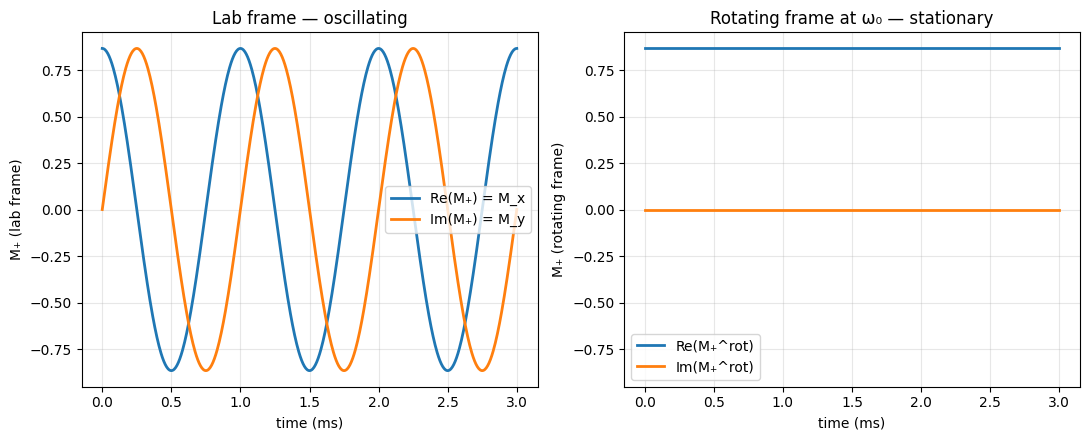

In [13]:
# Lab frame: complex magnetization
M_plus_lab = sol.y[0] + 1j * sol.y[1]

# Rotating frame: undo the e^(iω₀t) rotation
M_plus_rot = M_plus_lab * np.exp(-1j * omega0 * t_eval)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].plot(t_eval * 1e3, M_plus_lab.real, label='Re(M₊) = M_x', lw=2)
axs[0].plot(t_eval * 1e3, M_plus_lab.imag, label='Im(M₊) = M_y', lw=2)
axs[0].set_xlabel('time (ms)'); axs[0].set_ylabel('M₊ (lab frame)')
axs[0].set_title('Lab frame — oscillating')
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(t_eval * 1e3, M_plus_rot.real, label='Re(M₊^rot)', lw=2)
axs[1].plot(t_eval * 1e3, M_plus_rot.imag, label='Im(M₊^rot)', lw=2)
axs[1].set_xlabel('time (ms)'); axs[1].set_ylabel('M₊ (rotating frame)')
axs[1].set_title('Rotating frame at ω₀ — stationary')
axs[1].legend(); axs[1].grid(alpha=0.3)
axs[1].set_ylim(axs[0].get_ylim())

plt.tight_layout(); plt.show()

Beautiful: in the rotating frame the magnetization just sits there. We'll exploit this to trivially analyze RF pulses next time.

## 🎯 Try it yourself

Modify the notebook to explore:

1. **Off-axis B field.** Change `B = (0, 0, B0)` to `B = (Bx, 0, B0)` with a small Bx. What happens to the trajectory? (Spoiler: precession axis tilts, M now traces out a tilted circle. This is the seed of how RF excitation works in the rotating frame.)
2. **Equilibrium starting point.** Set `M_init = (0, 0, 1)`. Verify numerically that nothing happens, even after running for many milliseconds.
3. **Higher field strength.** Plot `M0_exact` vs `M0_high_T` for B₀ from 0.1 T up to a hypothetical 100 T. Where does the high-T approximation finally start to break down?
4. **Add relaxation (peek ahead).** Add the relaxation terms: `dM/dt += [-Mx/T2, -My/T2, (M0 - Mz)/T1]` with T₁ = 800 ms, T₂ = 80 ms. What happens? (You're now simulating free induction decay — the workhorse experiment of MRI.)
5. **Real Larmor frequency.** Replace `GAMMA_VIS` with the real `GAMMA_PROTON` and shrink `t_span` by the same factor (× GAMMA_VIS / GAMMA_PROTON). The trajectory looks identical, the time axis just shrinks to nanoseconds.

## ✅ What you've now done

- Built the working coordinate system and decomposition you'll use for the rest of the course.
- Verified the proportionality $M_0 \propto B_0/T_K$ — the *reason* MRI scanners are so big.
- Solved the Bloch equation in B₀ numerically and confirmed it matches the Larmor analytic solution.
- Confirmed that in a static field, $|\mathbf{M}|$ and $M_z$ are both conserved — only the transversal part rotates.
- Met the rotating-frame trick that will make the next lecture tractable.

**Up next (Day 3 in the roadmap, but covered in the same PDF if you've gotten this far):** computing the Larmor frequency for any nucleus at any field strength, and starting to build out the full picture of excitation.